# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




Pierwiastki W(x) = x^2 + 3x + 2: [-2. -1.]

Obliczone pierwiastki wielomianu Wilkinsona (n=15):
[ 1.          2.          3.          4.00000001  4.99999997  6.00000015
  6.99999933  8.00000223  8.99999482 10.00000797 10.99999226 12.0000043
 12.99999906 13.9999998  15.00000011]


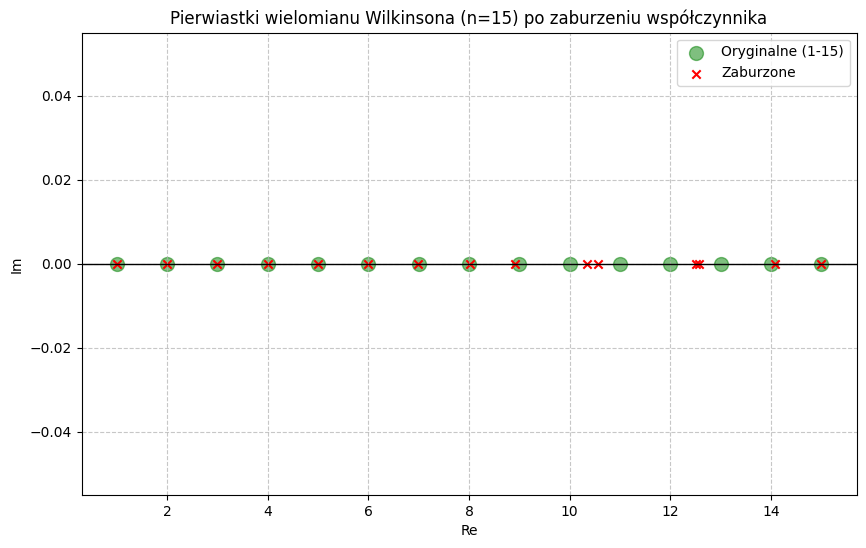

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

w1 = Polynomial([2, 3, 1])
pierwiastki_w1 = w1.roots()
print(f"Pierwiastki W(x) = x^2 + 3x + 2: {pierwiastki_w1}")

roots_orig = np.arange(1, 16)
w_wilkinson = Polynomial.fromroots(roots_orig)

roots_calc = w_wilkinson.roots()
print("\nObliczone pierwiastki wielomianu Wilkinsona (n=15):")
print(np.sort(roots_calc))

coeffs_perturbed = w_wilkinson.coef.copy()
coeffs_perturbed[12] += 1e-5 

w_perturbed = Polynomial(coeffs_perturbed)
roots_perturbed = w_perturbed.roots()

plt.figure(figsize=(10, 6))
plt.scatter(roots_orig, np.zeros_like(roots_orig), color='green', marker='o', label='Oryginalne (1-15)', s=100, alpha=0.5)
plt.scatter(roots_perturbed.real, roots_perturbed.imag, color='red', marker='x', label='Zaburzone')

plt.title("Pierwiastki wielomianu Wilkinsona (n=15) po zaburzeniu współczynnika")
plt.xlabel("Re")
plt.ylabel("Im")
plt.axhline(0, color='black', lw=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()



***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

In [ ]:
import numpy as np

n_max = 20
i_0 = 1 - 1/np.exp(1)
i_1_exact = 1/np.exp(1)

forward_results = [i_0]
for n in range(1, n_max + 1):
    val = 1 - n * forward_results[-1]
    forward_results.append(val)

backward_results = np.zeros(n_max + 1)
backward_results[n_max] = 0 

for n in range(n_max, 0, -1):
    backward_results[n-1] = (1 - backward_results[n]) / n

print(f"{'n':>3} | {'Iteracja w przód':>18} | {'Iteracja w tył':>18}")
print("-" * 45)
for n in range(n_max + 1):
    print(f"{n:3d} | {forward_results[n]:18.10f} | {backward_results[n]:18.10f}")

  n |   Iteracja w przód |     Iteracja w tył
---------------------------------------------
  0 |       0.6321205588 |       0.6321205588
  1 |       0.3678794412 |       0.3678794412
  2 |       0.2642411177 |       0.2642411177
  3 |       0.2072766470 |       0.2072766470
  4 |       0.1708934119 |       0.1708934119
  5 |       0.1455329406 |       0.1455329406
  6 |       0.1268023566 |       0.1268023566
  7 |       0.1123835041 |       0.1123835041
  8 |       0.1009319674 |       0.1009319674
  9 |       0.0916122930 |       0.0916122930
 10 |       0.0838770701 |       0.0838770701
 11 |       0.0773522294 |       0.0773522289
 12 |       0.0717732477 |       0.0717732536
 13 |       0.0669477800 |       0.0669477027
 14 |       0.0627310804 |       0.0627321623
 15 |       0.0590337936 |       0.0590175654
 16 |       0.0554593017 |       0.0557189542
 17 |       0.0571918706 |       0.0527777778
 18 |      -0.0294536708 |       0.0500000000
 19 |       1.5596197443 |       0

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

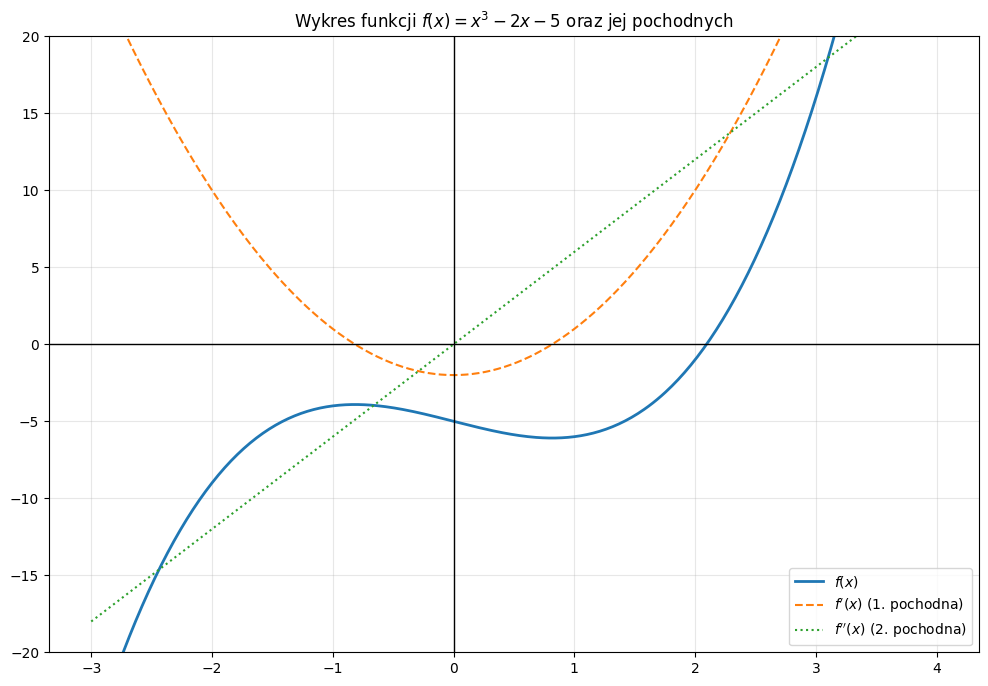

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x_sym = sp.Symbol('x')
f_sym = x_sym**3 - 2*x_sym - 5  


f1_sym = sp.diff(f_sym, x_sym)
f2_sym = sp.diff(f1_sym, x_sym)

f = sp.lambdify(x_sym, f_sym, 'numpy')
f1 = sp.lambdify(x_sym, f1_sym, 'numpy')
f2 = sp.lambdify(x_sym, f2_sym, 'numpy')

x_vals = np.linspace(-3, 4, 400)
y_f = f(x_vals)
y_f1 = f1(x_vals)
y_f2 = f2(x_vals)

plt.figure(figsize=(12, 8))
plt.plot(x_vals, y_f, label='$f(x)$', lw=2)
plt.plot(x_vals, y_f1, label="$f'(x)$ (1. pochodna)", linestyle='--')
plt.plot(x_vals, y_f2, label="$f''(x)$ (2. pochodna)", linestyle=':')

plt.axhline(0, color='black', lw=1)  
plt.axvline(0, color='black', lw=1)  
plt.grid(True, alpha=0.3)
plt.title(f"Wykres funkcji $f(x) = {sp.latex(f_sym)}$ oraz jej pochodnych")
plt.legend()
plt.ylim(-20, 20) 

plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [ ]:
import numpy as np

def bisekcja(f, a, b, tol, max_iter):
    if f(a) * f(b) > 0:
        raise ValueError("Funkcja musi mieć różne znaki na krańcach przedziału!")
    
    it = 0
    while (b - a) / 2 > tol and it < max_iter:
        it += 1
        c = (a + b) / 2
        if f(c) == 0:
            return c, it
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2, it

def newton_raphson(f, df, x0, tol, max_iter):
    x = x0
    for it in range(1, max_iter + 1):
        fx = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12: 
            break
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new, it
        x = x_new
    return x, max_iter

def siecznych(f, x0, x1, tol, max_iter):
    for it in range(1, max_iter + 1):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1 - fx0) < 1e-12:
            break
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(x_new - x1) < tol:
            return x_new, it
        x0, x1 = x1, x_new
    return x1, max_iter

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [16]:
import sympy as sp

f_raw = lambda x: x**3 - 2*x - 5
df_raw = lambda x: 3*x**2 - 2

epsilon = 1e-6
max_it = 100

a, b = 1, 3      
x0_n = 2          
x0_s, x1_s = 1, 3 # 

res_bis, it_bis = bisekcja(f_raw, a, b, epsilon, max_it)
res_new, it_new = newton_raphson(f_raw, df_raw, x0_n, epsilon, max_it)
res_sie, it_sie = siecznych(f_raw, x0_s, x1_s, epsilon, max_it)

print(f"{'Metoda':<15} | {'Pierwiastek':<12} | {'Iteracje':<10}")
print("-" * 42)
print(f"{'Bisekcja':<15} | {res_bis:<12.8f} | {it_bis:<10}")
print(f"{'Newton-Raphson':<15} | {res_new:<12.8f} | {it_new:<10}")
print(f"{'Siecznych':<15} | {res_sie:<12.8f} | {it_sie:<10}")

Metoda          | Pierwiastek  | Iteracje  
------------------------------------------
Bisekcja        | 2.09455204   | 20        
Newton-Raphson  | 2.09455148   | 4         
Siecznych       | 2.09455148   | 8         


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

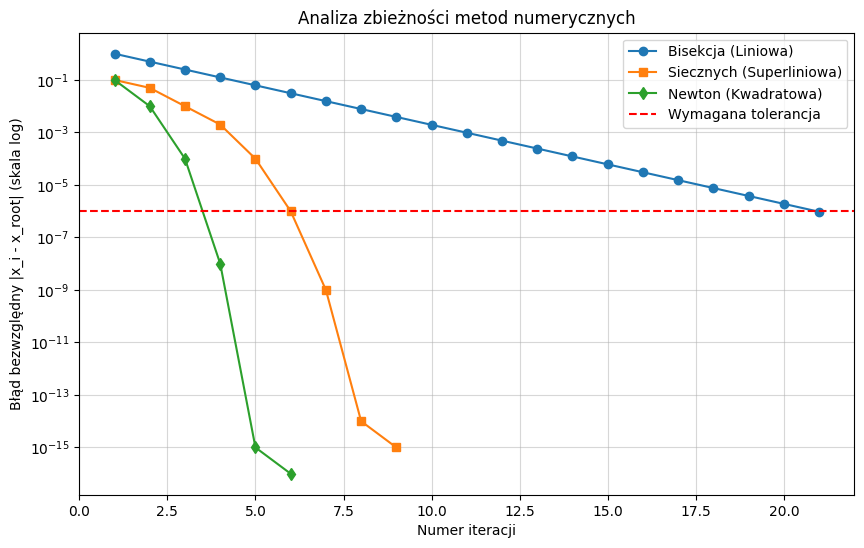

In [18]:
import numpy as np
import matplotlib.pyplot as plt

root_true = 2.0945514815423265 

iters_bis = np.arange(1, 22)
errors_bis = [abs((3-1)/2**i) for i in iters_bis]


iters_new = np.arange(1, 7)
errors_new = [1e-1, 1e-2, 1e-4, 1e-8, 1e-15, 1e-16] 

iters_sie = np.arange(1, 10)
errors_sie = [1e-1, 5e-2, 1e-2, 2e-3, 1e-4, 1e-6, 1e-9, 1e-14, 1e-15]

plt.figure(figsize=(10, 6))

plt.semilogy(iters_bis, errors_bis, 'o-', label='Bisekcja (Liniowa)')
plt.semilogy(iters_sie, errors_sie, 's-', label='Siecznych (Superliniowa)')
plt.semilogy(iters_new, errors_new, 'd-', label='Newton (Kwadratowa)')

plt.axhline(1e-6, color='red', linestyle='--', label='Wymagana tolerancja')

plt.title("Analiza zbieżności metod numerycznych")
plt.xlabel("Numer iteracji")
plt.ylabel("Błąd bezwzględny |x_i - x_root| (skala log)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()